# 1. Imports

In [122]:
import pandas as pd                 # Manejar DataFrames
from pathlib import Path            # Manejar rutas
import matplotlib.pyplot as plt     # Gráficos matplotlib
import seaborn as sns               # Gráficos seaborn
from matplotlib.patches import Wedge

# 2. Get data

Obtener dirección de carpetas necesarias

In [123]:
PROJECT_ROOT = Path.cwd().parent
print(PROJECT_ROOT)

c:\Users\Carlos\Documents\Ingenieria_informatica\Proyectos_datascience\2_titanic


In [124]:
FIGURES_PATH = PROJECT_ROOT / 'outputs' / 'figures'
print(FIGURES_PATH)

c:\Users\Carlos\Documents\Ingenieria_informatica\Proyectos_datascience\2_titanic\outputs\figures


Leer train y test

In [125]:
df = pd.read_csv(PROJECT_ROOT / 'data' / 'raw' / 'train.csv')

In [126]:
df_test = pd.read_csv(PROJECT_ROOT / 'data' / 'raw' / 'test.csv')

# 3. Initial analysis

Info

In [127]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [128]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


Head

In [129]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [130]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


Describe

In [131]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [132]:
df_test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


# 4. Raw EDA

Esto será una exploración inicial de los datos sucios

Vamos a generar una constante para siempre organizar en orden 0-1, o sea "Not survived" y "Survived". Otra constante para el orden en palabras. Y otra para definir colores para cada valor.

In [133]:
SURVIVED_ORDER = [0, 1]
SURVIVED_ORDER_STR = ['Not survived', 'Survived']
SURVIVED_COLORS = ["#ff4343", "#3a68fd"]

Además crearemos un DataFrame que de sobrevivientes y otro de no sobrevivientes, lo cual puede ayudar en ciertos casos.

In [134]:
df_survivors = df[df['Survived'] == 1]
df_no_survivors = df[df['Survived'] == 0]

## 4.1 Survival distribution

Contar

In [135]:
count_survived = df['Survived'].value_counts().reindex(SURVIVED_ORDER)
count_survived

Survived
0    549
1    342
Name: count, dtype: int64

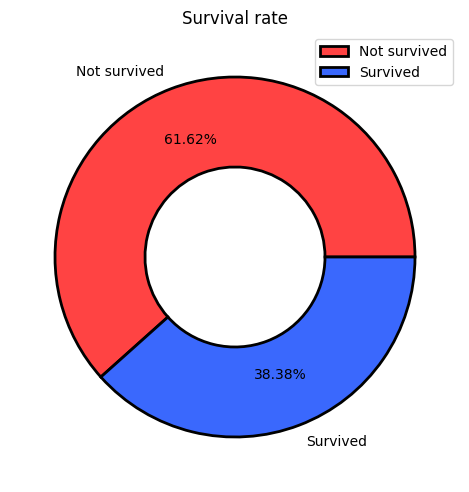

In [163]:
plt.pie(
    count_survived,
    labels=['Not survived', 'Survived'],
    autopct='%1.2f%%',
    pctdistance=0.7,
    wedgeprops={
        'edgecolor': 'black',
        'linewidth': 2,
        'width': 0.5
    },
    colors=SURVIVED_COLORS
)

plt.legend()
plt.tight_layout()
plt.title('Survival rate')

plt.savefig(FIGURES_PATH / '01_survival_rate.png', bbox_inches='tight')
plt.show()

## 4.2 Pclass

### 4.2.1 Proportions of Pclass

In [137]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [138]:
count_total_pclass = df['Pclass'].value_counts().reindex([1, 2, 3])
count_total_pclass

Pclass
1    216
2    184
3    491
Name: count, dtype: int64

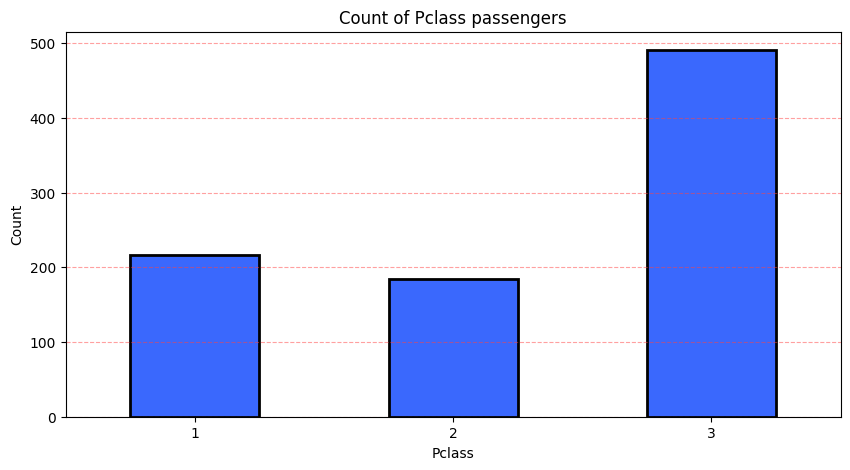

In [139]:
plt.figure(figsize=(10, 5))

count_total_pclass.plot(
    kind='bar',
    color=SURVIVED_COLORS[1],
    edgecolor='black',
    linewidth=2

)
plt.grid(axis='y', linestyle='--', alpha=0.5, color=SURVIVED_COLORS[0])

plt.xticks(rotation=0)

plt.xlabel('Pclass')
plt.ylabel('Count')
plt.title('Count of Pclass passengers')


plt.savefig(FIGURES_PATH / '02_count_pclass.png', bbox_inches='tight')
plt.show()

### 4.2.2 Survived rate by Pclass

Contar por cada tipo de Pclass

In [140]:
count_pclass_1 = df[df['Pclass'] == 1]['Survived'].value_counts()
count_pclass_1

Survived
1    136
0     80
Name: count, dtype: int64

In [141]:
count_pclass_2 = df[df['Pclass'] == 2]['Survived'].value_counts()
count_pclass_2

Survived
0    97
1    87
Name: count, dtype: int64

In [142]:
count_pclass_3 = df[df['Pclass'] == 3]['Survived'].value_counts()
count_pclass_3

Survived
0    372
1    119
Name: count, dtype: int64

Visualizar cada proporción

In [143]:
pclass_groups_data = [count_pclass_1, count_pclass_2, count_pclass_3]
pclass_options = ['Pclass 1', 'Pclass 2', 'Pclass 3']

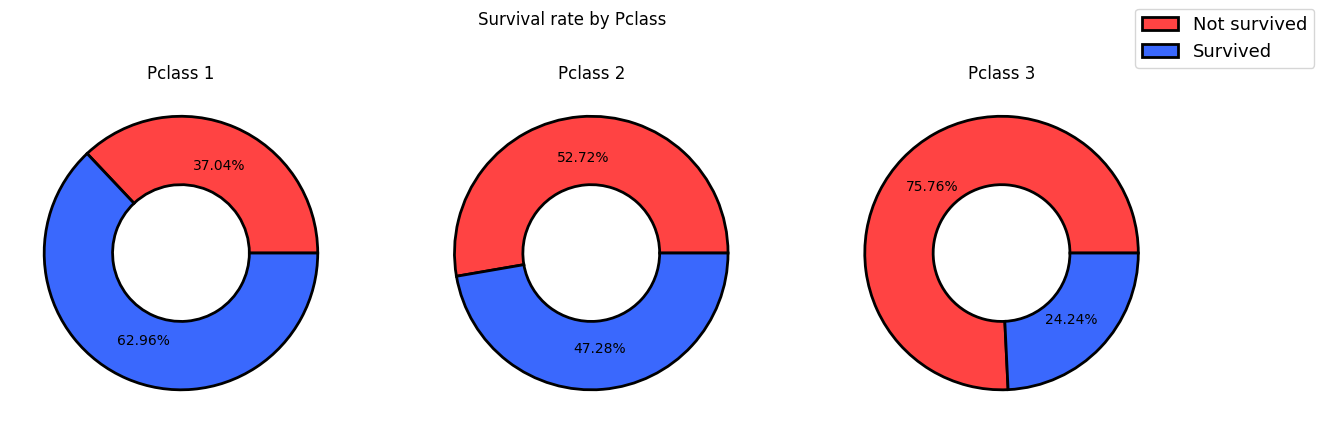

In [144]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

# Iterar sobre cada grupo, obteniendo indice para el axes y nombre de la pclass (se hace reindex para ordenar la data en orden 0-1)
for i, (data, pclass) in enumerate(zip(pclass_groups_data, pclass_options)):
    data = data.reindex(SURVIVED_ORDER)
    ax[i].pie(
        data,
        colors=SURVIVED_COLORS,
        autopct='%1.2f%%',
        wedgeprops={
            'width': 0.5,
            'edgecolor': 'black',
            'linewidth': 2
        },
        pctdistance=0.7,
    )
    ax[i].set_title(pclass, pad=-50)

fig.legend(SURVIVED_ORDER_STR, fontsize='13')

fig.suptitle('Survival rate by Pclass')

plt.savefig(FIGURES_PATH / '03_survival_rate_by_pclass', bbox_inches='tight')
plt.show()

## 4.3 Sex

### 4.3.1 Sex distribution

In [145]:
count_sex = df['Sex'].value_counts()
count_sex

Sex
male      577
female    314
Name: count, dtype: int64

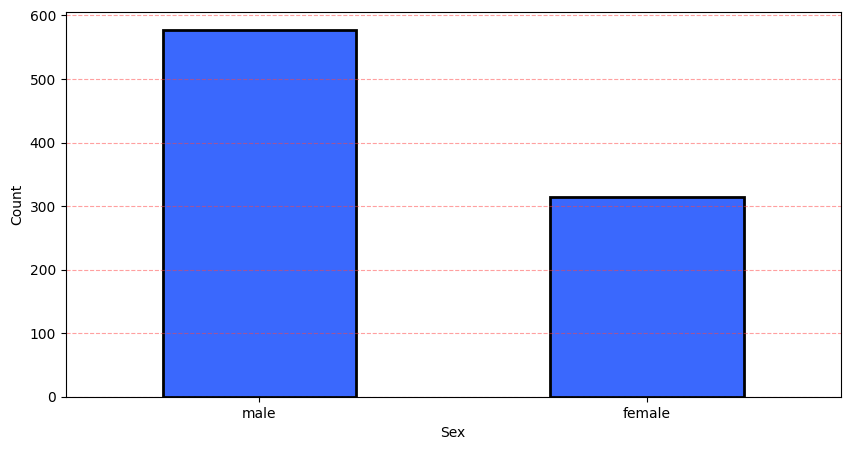

In [146]:
plt.figure(figsize=(10, 5))

count_sex.plot(
    kind='bar',
    color=SURVIVED_COLORS[1],
    edgecolor='black',
    linewidth=2
)

plt.grid(axis='y', linestyle='--', alpha=0.5, color=SURVIVED_COLORS[0])

plt.xticks(rotation=0)

plt.xlabel('Sex')
plt.ylabel('Count')

plt.savefig(FIGURES_PATH / '04_count_sex.png', bbox_inches='tight')
plt.show()

### 4.3.2 Survived rate by Sex

In [147]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [148]:
group_sex_survived = df.groupby('Sex')['Survived'].value_counts().unstack()
group_sex_survived

Survived,0,1
Sex,,
female,81,233
male,468,109


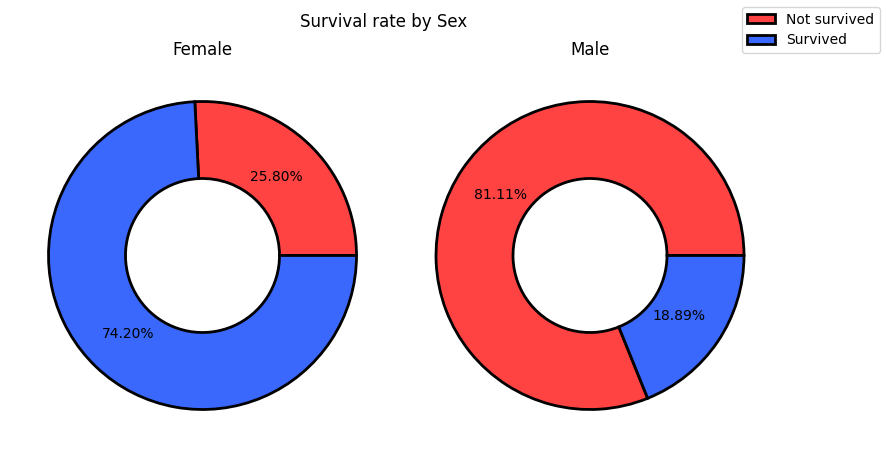

In [149]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

for i, sex in enumerate(group_sex_survived.index):
    survival_values = group_sex_survived.loc[sex]
    survival_values = survival_values.reindex(SURVIVED_ORDER)

    ax[i].pie(
        survival_values,
        colors=SURVIVED_COLORS,
        autopct='%1.2f%%',
        pctdistance=0.7,
        wedgeprops={
            'width': 0.5,
            'linewidth': 2,
            'edgecolor': 'black'
        }
    )
    ax[i].set_title(sex.capitalize())

fig.subplots_adjust(wspace=0)
fig.legend(SURVIVED_ORDER_STR)
fig.suptitle('Survival rate by Sex')

plt.savefig(FIGURES_PATH / '05_survival_rate_by_sex.png', bbox_inches='tight')
plt.show()

## 4.4 Age

### 4.4.1 Age distribution

In [150]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


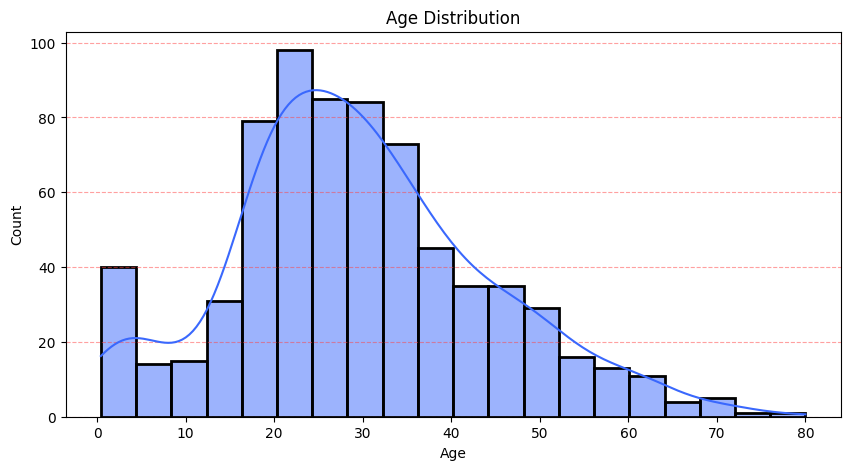

In [151]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['Age'],
    color=SURVIVED_COLORS[1],
    edgecolor='black',
    linewidth=2,
    kde=True
)

plt.grid(axis='y', linestyle='--', alpha=0.5, color=SURVIVED_COLORS[0])

plt.title('Age Distribution')

plt.savefig(FIGURES_PATH / '06_age_distribution.png')
plt.show()

### 4.4.2 Age distribution in survivors/no survivors

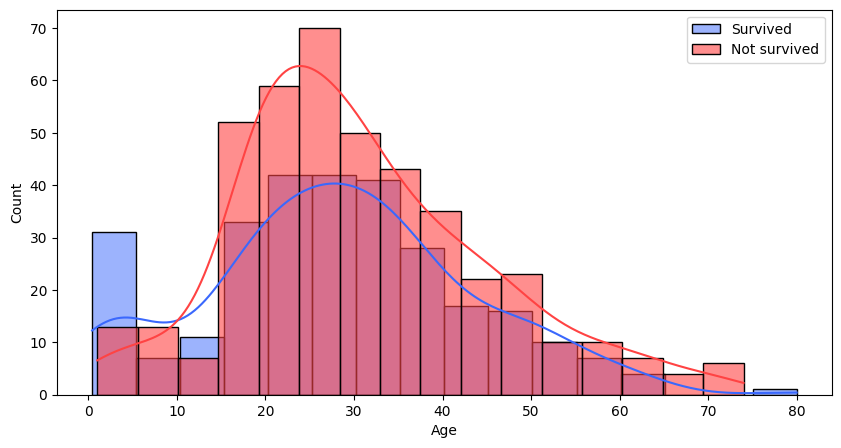

In [152]:
plt.figure(figsize=(10, 5))


sns.histplot(
    df_survivors['Age'],
    color=SURVIVED_COLORS[1],
    label='Survived',
    kde=True
)

sns.histplot(
    df_no_survivors['Age'],
    color=SURVIVED_COLORS[0],
    alpha=0.6,
    label='Not survived',
    kde=True
)

plt.legend()

plt.show()

### 4.4.3 See age groups survivors rates

Dividiremos en grupos cada 10 años para ver probabilidades de sobrevivir

In [153]:
bins = [i for i in range(0, 100, 10)]

age_groups = pd.cut(df['Age'], bins=bins)

# observed=True es para que si hay un grupo que no tiene ningún registro, no considera ese grupo
age_group_surv_rate = df.groupby(age_groups, observed=True)['Survived'].mean()
age_group_surv_rate

Age
(0, 10]     0.593750
(10, 20]    0.382609
(20, 30]    0.365217
(30, 40]    0.445161
(40, 50]    0.383721
(50, 60]    0.404762
(60, 70]    0.235294
(70, 80]    0.200000
Name: Survived, dtype: float64

Ahora graficar

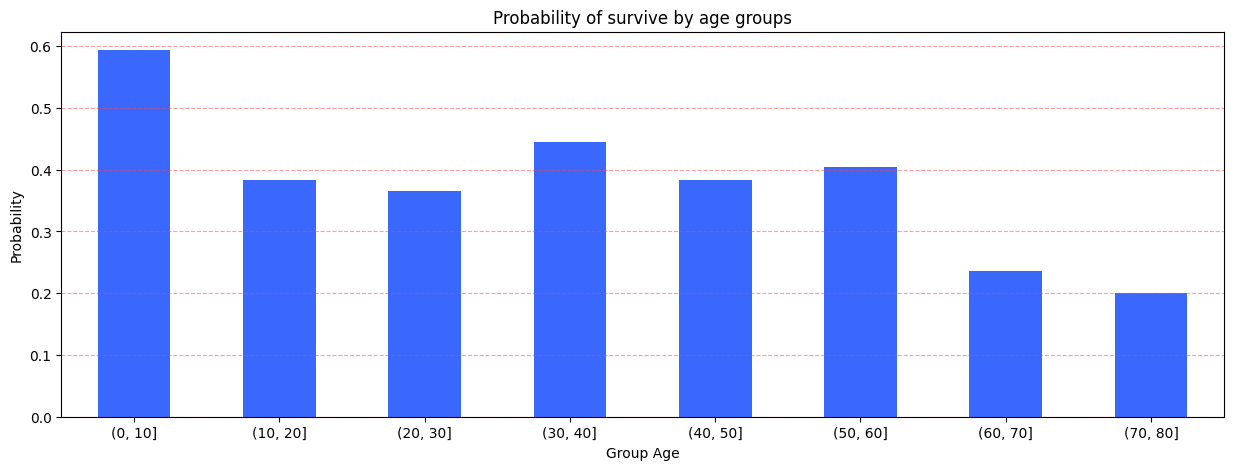

In [154]:
plt.figure(figsize=(15, 5))

age_group_surv_rate.plot(
    kind='bar',
    color=SURVIVED_COLORS[1]
)

plt.grid(axis='y', color=SURVIVED_COLORS[0], linestyle='--', alpha=0.5)

plt.xlabel('Group Age')
plt.ylabel('Probability')

plt.xticks(rotation=0)

plt.title('Probability of survive by age groups')

plt.savefig(FIGURES_PATH / '07_probability_of_survive_by_age_groups.png', bbox_inches='tight')
plt.show()

## 4.5 SibSp

In [155]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Contar cada categoría

In [156]:
value_counts_of_sibsp = df['SibSp'].value_counts()
value_counts_of_sibsp

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

Obtener probabilidades de sobrevivencia de cada uno

In [157]:
sibsp_group_surv_rate = df.groupby('SibSp')['Survived'].mean()
sibsp_group_surv_rate

SibSp
0    0.345395
1    0.535885
2    0.464286
3    0.250000
4    0.166667
5    0.000000
8    0.000000
Name: Survived, dtype: float64

Graficar

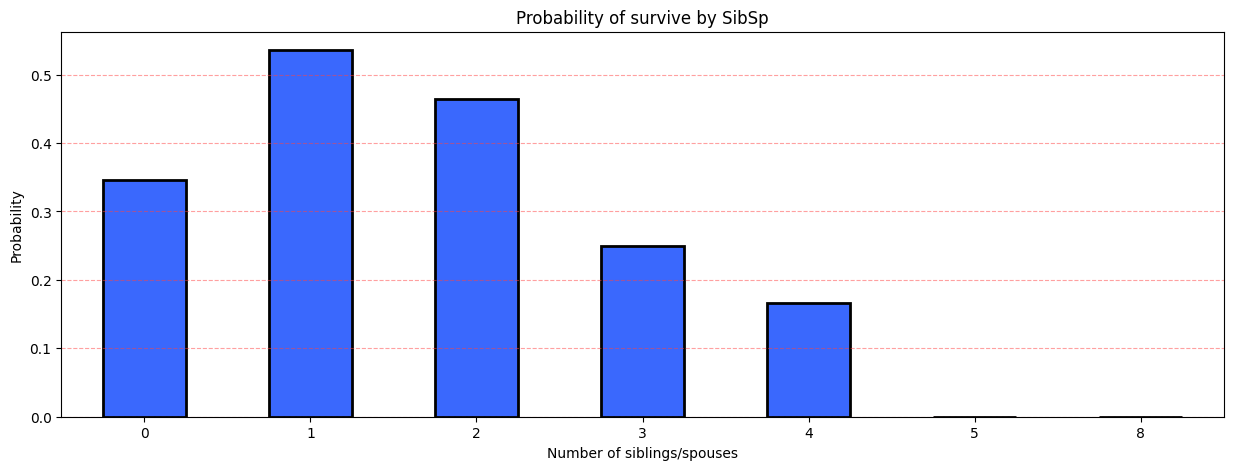

In [158]:
plt.figure(figsize=(15, 5))

sibsp_group_surv_rate.plot(
    kind='bar',
    color=SURVIVED_COLORS[1],
    edgecolor='black',
    linewidth=2
)

plt.grid(axis='y', color=SURVIVED_COLORS[0], linestyle='--', alpha=0.5)

plt.xlabel('Number of siblings/spouses')
plt.ylabel('Probability')

plt.xticks(rotation=0)

plt.title('Probability of survive by SibSp')

plt.savefig(FIGURES_PATH / '08_probability_of_survive_by_sibsp.png', bbox_inches='tight')
plt.show()

## 4.6 Parch

In [159]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Contar categorías

In [160]:
value_counts_of_parch = df['Parch'].value_counts()
value_counts_of_parch

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

Ver probabilidades de sobreviviencia

In [161]:
parch_group_surv_rate = df.groupby('Parch')['Survived'].mean()
parch_group_surv_rate

Parch
0    0.343658
1    0.550847
2    0.500000
3    0.600000
4    0.000000
5    0.200000
6    0.000000
Name: Survived, dtype: float64

Graficar

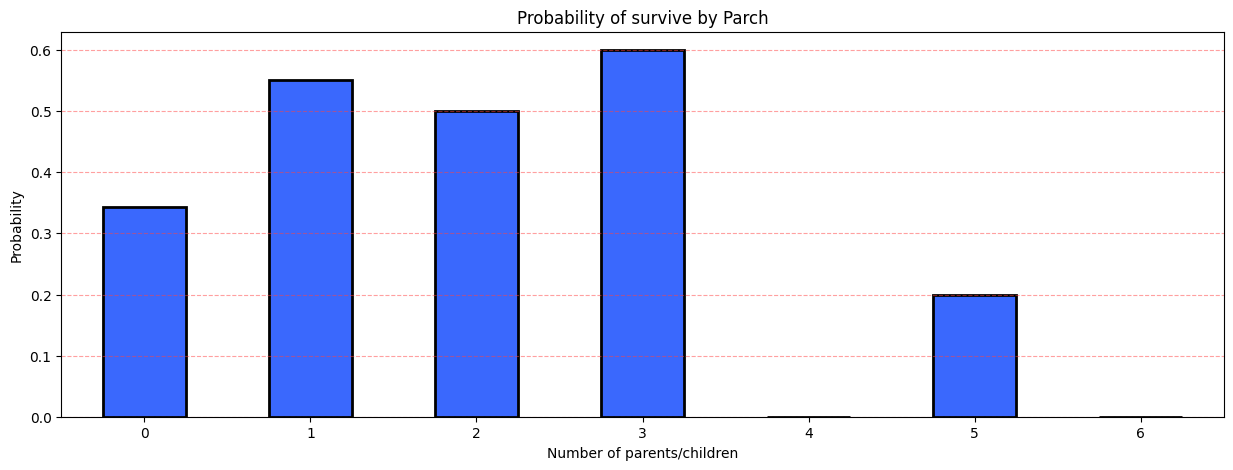

In [162]:
plt.figure(figsize=(15, 5))

parch_group_surv_rate.plot(
    kind='bar',
    color=SURVIVED_COLORS[1],
    edgecolor='black',
    linewidth=2
)

plt.grid(axis='y', color=SURVIVED_COLORS[0], linestyle='--', alpha=0.5)

plt.title('Probability of survive by Parch')

plt.xlabel('Number of parents/children')
plt.ylabel('Probability')

plt.xticks(rotation=0)


plt.savefig(FIGURES_PATH / '09_probability_of_survive_by_parch.png', bbox_inches='tight')
plt.show()

# 5. Clean data

## 5.1 Age

Como desde ya tenemos un dataset con los datos de entrenamiento preseleccionados, rellenaremos los datos nulos de 'Age' con mediana.

In [11]:
median_age = df['Age'].median()
median_age

np.float64(28.0)

In [ ]:
df['Age'] = df['Age'].fillna()